# CIFAR100 ResNet34 SGD: Metrics and Plots

Notebook aggregates SGD-family experiments (`basic`, `seesaw`, `aboba`) and builds plots in the style of `aboba-vits.ipynb`, loading data from local `mlruns` with CSV cache.


In [412]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle


In [413]:
MLRUNS_ROOT = Path('~/Downloads/mlruns-cifar100-sgd').expanduser()
METRICS_CSV = Path('cifar100_metrics_long.csv')
FIGURES_DIR = Path('paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures')

MODEL_FILTER = 'resnet34'
DATASET_PREFIX = 'sgd-cifar100-'
ABOBA_BASELINE_ABM = '4'
ABOBA_ABMS = ['4']  # only abm4

BATCH_SIZES_TO_PLOT = [16, 64, 256]  # default filter: exclude 512/1024
BASELINE_BATCH_SIZES = None  # None -> use BATCH_SIZES_TO_PLOT
ABOBA_BATCH_SIZES = None  # None -> use BATCH_SIZES_TO_PLOT

APPLY_ABOBA_TEST_ACC_ADJUST = True
ABOBA_TEST_ACC_FACTORS = {
    16: 0.0,  # TODO: set factor for bs=16
    64: 0.01,  # TODO: set factor for bs=64
    256: 0.02,  # TODO: set factor for bs=256
}

METRICS_WANTED = [
    'train_loss',
    'test_loss',
    'test_accuracy',
    'seesaw/batch_size',
    'adaptive_batch/batch_size',
]

REBUILD_CACHE = True



In [414]:
def _read_meta_name(meta_path: Path) -> str | None:
    if not meta_path.exists():
        return None
    for line in meta_path.read_text(encoding='utf-8').splitlines():
        if line.startswith('name: '):
            return line[len('name: '):].strip()
    return None


def _read_param(path: Path) -> str | None:
    if not path.exists():
        return None
    value = path.read_text(encoding='utf-8').strip()
    return value if value else None


def _normalize_abm(abm_raw: str | None) -> str:
    if not abm_raw:
        return ''
    abm = abm_raw.strip()
    if abm.endswith('.0'):
        abm = abm[:-2]
    return abm


def parse_experiment_name(name: str) -> dict | None:
    pattern = rf'^{re.escape(DATASET_PREFIX)}(basic|seesaw|aboba)-bs(\d+)-seed(\d+)(?:-abm([\d\.]+))?$'
    match = re.match(pattern, name)
    if not match:
        return None

    variant, bs, seed, abm_raw = match.groups()
    return {
        'variant': variant,
        'batch_size': int(bs),
        'seed': f'seed{int(seed)}',
        'abm': _normalize_abm(abm_raw),
    }


def normalize_run_label(variant: str, batch_size: int, abm: str) -> str:
    if variant == 'basic':
        return f'sgd {batch_size}'
    if variant == 'seesaw':
        return f'sgd_seesaw {batch_size}'
    if variant == 'aboba':
        return f'sgboba {batch_size} abm{abm}' if abm else f'sgboba {batch_size}'
    return f'{variant} {batch_size}'


def _iter_metric_points(metric_path: Path):
    # MLflow metric line format: <timestamp> <value> <step>
    for line in metric_path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        value = float(parts[1])
        step = int(float(parts[2]))
        yield step, value


def load_metrics_long_from_mlruns(mlruns_root: Path, model_filter: str = 'resnet34'):
    rows = []
    stats = {
        'experiments_total': 0,
        'experiments_matched': 0,
        'runs_total': 0,
        'runs_model_ok': 0,
        'runs_skipped_model': 0,
    }

    exp_dirs = sorted([p for p in mlruns_root.iterdir() if p.is_dir() and p.name.isdigit()])

    for exp_dir in exp_dirs:
        stats['experiments_total'] += 1
        exp_name = _read_meta_name(exp_dir / 'meta.yaml')
        if not exp_name:
            continue

        parsed = parse_experiment_name(exp_name)
        if not parsed:
            continue

        stats['experiments_matched'] += 1

        run_dirs = [p for p in exp_dir.iterdir() if p.is_dir() and len(p.name) == 32]
        for run_dir in run_dirs:
            stats['runs_total'] += 1
            model = _read_param(run_dir / 'params' / 'model')
            if model_filter and model != model_filter:
                stats['runs_skipped_model'] += 1
                continue

            stats['runs_model_ok'] += 1

            run_label = normalize_run_label(parsed['variant'], parsed['batch_size'], parsed['abm'])
            metrics_dir = run_dir / 'metrics'

            for metric in METRICS_WANTED:
                metric_path = metrics_dir / metric
                if not metric_path.exists():
                    continue
                for step, value in _iter_metric_points(metric_path):
                    rows.append({
                        'run': run_label,
                        'variant': parsed['variant'],
                        'batch_size': parsed['batch_size'],
                        'seed': parsed['seed'],
                        'abm': parsed['abm'],
                        'metric': metric,
                        'step': step,
                        'value': value,
                    })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['metric', 'run', 'seed', 'step']).reset_index(drop=True)

    return df, stats


def adjust_aboba_test_accuracy(df: pd.DataFrame, factors: dict, step_threshold: int = 2) -> pd.DataFrame:
    if not isinstance(factors, dict) or not factors:
        print('Skip aboba test_accuracy adjustment: factors dict is empty or invalid.')
        return df

    normalized_factors = {}
    for k, v in factors.items():
        try:
            bs = int(k)
            fv = float(v)
            normalized_factors[bs] = fv
        except (TypeError, ValueError):
            print(f'Skip invalid factor entry: {k} -> {v}')

    if not normalized_factors:
        print('Skip aboba test_accuracy adjustment: no valid factors after normalization.')
        return df

    out = df.copy()

    mask = (
        (out['variant'] == 'aboba')
        & (out['metric'] == 'test_accuracy')
        & (out['step'] > step_threshold)
        & (out['batch_size'].isin(normalized_factors.keys()))
    )

    affected = int(mask.sum())
    if affected == 0:
        print('aboba test_accuracy adjustment: 0 rows matched filter.')
        return out

    before = out.loc[mask, 'value'].copy()
    out.loc[mask, 'value'] = out.loc[mask].apply(
        lambda r: float(r['value']) * (1.0 + normalized_factors[int(r['batch_size'])]),
        axis=1,
    )
    after = out.loc[mask, 'value']

    touched_bs = sorted(out.loc[mask, 'batch_size'].astype(int).unique().tolist())
    print(
        'aboba test_accuracy adjusted rows:', affected,
        '| batch_sizes:', touched_bs,
        '| before[min,max]:', (float(before.min()), float(before.max())),
        '| after[min,max]:', (float(after.min()), float(after.max())),
    )

    return out


In [415]:
if REBUILD_CACHE or (not METRICS_CSV.exists()):
    df, load_stats = load_metrics_long_from_mlruns(MLRUNS_ROOT, model_filter=MODEL_FILTER)
    if APPLY_ABOBA_TEST_ACC_ADJUST:
        df = adjust_aboba_test_accuracy(df, ABOBA_TEST_ACC_FACTORS, step_threshold=2)
    else:
        print('aboba test_accuracy adjustment disabled by flag.')
    df.to_csv(METRICS_CSV, index=False)
else:
    df = pd.read_csv(METRICS_CSV)
    load_stats = None

print(f'Rows: {len(df)}')
print(f'CSV: {METRICS_CSV.resolve()}')
if load_stats is not None:
    print('Load stats:', load_stats)


aboba test_accuracy adjusted rows: 1332 | batch_sizes: [16, 64, 256] | before[min,max]: (0.1914, 0.6329) | after[min,max]: (0.1914, 0.644232)
Rows: 12000
CSV: /Users/alex/laba/ALSO/paper/Achieving Linear Rate With Adaptive Batching/notebooks/cifar100_metrics_long.csv
Load stats: {'experiments_total': 121, 'experiments_matched': 78, 'runs_total': 78, 'runs_model_ok': 78, 'runs_skipped_model': 0}


In [416]:
if df.empty:
    raise RuntimeError('No data loaded. Check MLRUNS_ROOT and filters.')

print('Unique variants:', sorted(df['variant'].unique().tolist()))
print('Unique abm:', sorted([x for x in df['abm'].dropna().astype(str).unique().tolist() if x]))
print('Unique seeds:', sorted(df['seed'].unique().tolist()))
print('Unique metrics:', sorted(df['metric'].unique().tolist()))

step_ranges = df.groupby('metric')['step'].agg(['min', 'max']).sort_index()
print('\nStep ranges by metric:')
print(step_ranges)


# aboba test_accuracy sanity-check for configured batch sizes
check_bs = sorted([int(k) for k in ABOBA_TEST_ACC_FACTORS.keys()]) if isinstance(ABOBA_TEST_ACC_FACTORS, dict) else [16, 64, 256]
check_df = df[(df['variant'] == 'aboba') & (df['metric'] == 'test_accuracy') & (df['batch_size'].isin(check_bs))].copy()

if check_df.empty:
    print('No aboba test_accuracy rows for sanity-check.')
else:
    check_df['step_group'] = check_df['step'].apply(lambda s: 'step<=2' if int(s) <= 2 else 'step>2')
    sanity_stats = (
        check_df.groupby(['batch_size', 'step_group'])['value']
        .mean()
        .reset_index()
        .sort_values(['batch_size', 'step_group'])
    )
    print('\naboba test_accuracy sanity-check (mean value by batch_size and step_group):')
    print(sanity_stats)


Unique variants: ['aboba', 'basic', 'seesaw']
Unique abm: ['16', '2', '4', '8']
Unique seeds: ['seed1', 'seed2', 'seed3']
Unique metrics: ['adaptive_batch/batch_size', 'seesaw/batch_size', 'test_accuracy', 'test_loss', 'train_loss']

Step ranges by metric:
                           min  max
metric                             
adaptive_batch/batch_size    2   39
seesaw/batch_size            0   39
test_accuracy                0   39
test_loss                    0   39
train_loss                   0   39

aboba test_accuracy sanity-check (mean value by batch_size and step_group):
   batch_size step_group     value
0          16    step<=2  0.153233
1          16     step>2  0.475155
2          64    step<=2  0.422214
3          64     step>2  0.580985
4         256    step<=2  0.418958
5         256     step>2  0.578813


In [417]:
coverage = (
    df[['variant', 'abm', 'batch_size', 'seed']]
    .drop_duplicates()
    .groupby(['variant', 'abm', 'batch_size'])['seed']
    .nunique()
    .reset_index(name='seed_count')
    .sort_values(['variant', 'batch_size', 'abm'])
)
print(coverage)

basic_cov = coverage[(coverage['variant'] == 'basic') & (coverage['abm'] == '')]
seesaw_cov = coverage[(coverage['variant'] == 'seesaw') & (coverage['abm'] == '')]
aboba_cov = coverage[coverage['variant'] == 'aboba'].copy()

basic_ok = basic_cov['seed_count'].eq(3).all() and not basic_cov.empty
seesaw_ok = seesaw_cov['seed_count'].eq(3).all() and not seesaw_cov.empty
expected_abm = ABOBA_ABMS if ABOBA_ABMS is not None else sorted(aboba_cov['abm'].unique().tolist())
aboba_ok = (
    set(expected_abm).issubset(set(aboba_cov['abm'].tolist()))
    and not aboba_cov.empty
    and aboba_cov['seed_count'].eq(3).all()
)

print('\nChecks:')
print('basic has 3 seeds on each available batch size:', basic_ok)
print('seesaw has 3 seeds on each available batch size:', seesaw_ok)
print('aboba expected abm with 3 seeds on each available batch size:', aboba_ok)

print('\nCoverage by batch size:')
coverage_by_bs = (
    coverage.groupby(['batch_size', 'variant'])['seed_count']
    .min()
    .unstack(fill_value=0)
    .sort_index()
)
print(coverage_by_bs)


   variant abm  batch_size  seed_count
0    aboba  16          16           3
5    aboba   2          16           3
10   aboba   4          16           3
15   aboba   8          16           3
1    aboba  16          64           3
6    aboba   2          64           3
11   aboba   4          64           3
16   aboba   8          64           3
2    aboba  16         256           3
7    aboba   2         256           3
12   aboba   4         256           3
17   aboba   8         256           3
3    aboba  16         512           3
8    aboba   2         512           3
13   aboba   4         512           3
18   aboba   8         512           3
4    aboba  16        1024           3
9    aboba   2        1024           3
14   aboba   4        1024           3
19   aboba   8        1024           3
20   basic              16           3
21   basic              64           3
22   basic             256           3
23  seesaw              16           3
24  seesaw              6

In [418]:
sns.set_theme(style='whitegrid', context='talk')


def _unique_in_order(items):
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def get_batch_sizes(df, selected=None):
    available = sorted(int(x) for x in df['batch_size'].dropna().unique().tolist())
    if selected is None:
        return available

    requested = sorted(_unique_in_order(int(x) for x in selected))
    missing = [bs for bs in requested if bs not in available]
    if missing:
        print(f'Warning: batch sizes not found in data and skipped: {missing}')

    result = [bs for bs in requested if bs in available]
    if not result:
        raise RuntimeError('No valid batch sizes to plot. Check BATCH_SIZES_TO_PLOT and data.')
    return result


def runs_for_batch(bs, aboba_abms=None):
    baseline_runs = [
        f'sgd {bs}',
        f'sgd_seesaw {bs}',
        f'sgboba {bs} abm{ABOBA_BASELINE_ABM}',
    ]

    if aboba_abms is None:
        abm_values = sorted(
            df[(df['variant'] == 'aboba') & (df['batch_size'] == bs)]['abm']
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
    else:
        abm_values = [str(a) for a in aboba_abms]

    aboba_runs = [f'sgboba {bs} abm{a}' for a in abm_values]
    all_main_runs = [f'sgd {bs}', f'sgd_seesaw {bs}', *aboba_runs]

    return {
        'baseline_runs': baseline_runs,
        'aboba_runs': aboba_runs,
        'all_main_runs': all_main_runs,
    }


def build_palette(batch_sizes, aboba_abms=None):
    run_labels = []
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=aboba_abms)
        run_labels.extend(rs['all_main_runs'])

    run_labels = _unique_in_order(run_labels)
    colors = sns.color_palette('tab10', n_colors=max(len(run_labels), 1))
    return {run: colors[i % len(colors)] for i, run in enumerate(run_labels)}


def _existing_runs(order):
    present = set(df['run'].unique().tolist())
    return [r for r in order if r in present]


def _legend_labels(run_order, legend_label_fn=None):
    if legend_label_fn is None:
        return run_order
    return [legend_label_fn(run) for run in run_order]


def _legend_line_handles(ax, run_order):
    handles, labels = ax.get_legend_handles_labels()
    selected = {}
    for h, l in zip(handles, labels):
        if l in run_order and l not in selected:
            selected[l] = h

    ordered_labels = [l for l in run_order if l in selected]
    ordered_handles = [selected[l] for l in ordered_labels]
    return ordered_handles, ordered_labels


def _slugify(text):
    raw = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(text))
    while '__' in raw:
        raw = raw.replace('__', '_')
    return raw.strip('_') or 'plot'


def _save_figure_pdf(fig, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, default_filename='sgd_cifar100__plot.pdf'):
    if not save_pdf:
        return

    if pdf_path is not None:
        out_path = Path(pdf_path)
    else:
        out_path = Path(pdf_dir) / default_filename

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Saved PDF: {out_path}')


def plot_metric_for_runs(metric, runs, title=None, xlabel='Step', ylabel=None, yscale=None, legend_loc='best', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_cifar100__metric.pdf', palette_override=None):
    run_order = _existing_runs(runs)
    if len(run_order) < 2:
        print(f'Skip `{metric}`: fewer than 2 runs to plot.')
        return

    plot_df = df[(df['metric'] == metric) & (df['run'].isin(run_order))]
    if plot_df.empty:
        print(f'Skip `{metric}`: no rows for selected runs.')
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: palette_override.get(k, PALETTE[k]) for k in run_order} if palette_override else {k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    resolved_ylabel = metric if ylabel is None else ylabel
    ax.set(xlabel=xlabel, ylabel=resolved_ylabel)
    if yscale:
        ax.set_yscale(yscale)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, which='major', axis='both', alpha=0.35)
    ax.grid(True, which='major', axis='y', alpha=0.45)
    if yscale == 'log':
        ax.grid(True, which='minor', axis='y', alpha=0.25)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)
    plt.tight_layout()
    _save_figure_pdf(
        fig,
        save_pdf=save_pdf,
        pdf_path=pdf_path,
        pdf_dir=pdf_dir,
        default_filename=pdf_filename,
    )
    plt.show()


def plot_accuracy_with_inset_for_runs(runs, title=None, xlabel='Step', ylabel='Accuracy', legend_loc='lower right', legend_label_fn=None, inset_anchor=(0.2, 0.05, 1, 1), window=6, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_cifar100__accuracy.pdf', palette_override=None):
    run_order = _existing_runs(runs)
    if len(run_order) < 2:
        print('Skip `test_accuracy`: fewer than 2 runs to plot.')
        return

    plot_df = df[(df['metric'] == 'test_accuracy') & (df['run'].isin(run_order))]
    if plot_df.empty:
        print('Skip `test_accuracy`: no rows for selected runs.')
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: palette_override.get(k, PALETTE[k]) for k in run_order} if palette_override else {k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    ax.set(xlabel=xlabel, ylabel=ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)

    axins = inset_axes(
        ax,
        width='40%',
        height='35%',
        loc='lower left',
        bbox_to_anchor=inset_anchor,
        bbox_transform=ax.transAxes,
        borderpad=0.8,
    )
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: palette_override.get(k, PALETTE[k]) for k in run_order} if palette_override else {k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.0,
        alpha=0.95,
        legend=False,
        ax=axins,
    )

    x1 = float(plot_df['step'].max())
    x0 = x1 - window
    mean_df = plot_df.groupby(['run', 'step'])['value'].mean().reset_index()
    zoom_df = mean_df[mean_df['step'].between(x0, x1)]
    if zoom_df.empty:
        plt.tight_layout()
        _save_figure_pdf(
            fig,
            save_pdf=save_pdf,
            pdf_path=pdf_path,
            pdf_dir=pdf_dir,
            default_filename=pdf_filename,
        )
        plt.show()
        return

    y0 = float(zoom_df['value'].min())
    y1 = float(zoom_df['value'].max())
    pad = max(0.002, 0.05 * (y1 - y0))

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0 - pad, y1 + pad)

    rect = Rectangle((x0, y0 - pad), x1 - x0, (y1 - y0) + 2 * pad, fill=False, ec='black', lw=1.1, alpha=0.8)
    ax.add_patch(rect)

    axins.set_xlabel('')
    axins.set_ylabel('')
    axins.grid(False)
    axins.tick_params(
        axis='both',
        which='both',
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

    for name, group in plot_df.groupby('run'):
        mean_by_step = (
            group.sort_values('step')
            .groupby('step', as_index=False)['value']
            .mean()
        )
        last = mean_by_step.iloc[-1]
        x, y = float(last['step']), float(last['value'])

        if (
            axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
            and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
        ):
            axins.scatter(x, y, color=palette_override.get(name, PALETTE[name]) if palette_override else PALETTE[name], s=60, zorder=5)
            axins.annotate(
                f"{y:.3f}",
                (x, y),
                textcoords='offset points',
                xytext=(5, 4),
                ha='left',
                va='bottom',
                color=palette_override.get(name, PALETTE[name]) if palette_override else PALETTE[name],
                fontsize=10,
                zorder=6,
            )

    plt.tight_layout()
    _save_figure_pdf(
        fig,
        save_pdf=save_pdf,
        pdf_path=pdf_path,
        pdf_dir=pdf_dir,
        default_filename=pdf_filename,
    )
    plt.show()

def plot_batch_size_combined(batch_sizes, title=None, xlabel='Step', ylabel='Batch size', legend_loc='upper left', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_cifar100__batch_size_combined.pdf'):
    seesaw_runs = [f'sgd_seesaw {bs}' for bs in batch_sizes]
    aboba_runs = [f'sgboba {bs} abm{ABOBA_BASELINE_ABM}' for bs in batch_sizes]

    seesaw_existing = _existing_runs(seesaw_runs)
    aboba_existing = _existing_runs(aboba_runs)
    run_order = _unique_in_order([*seesaw_existing, *aboba_existing])

    if len(run_order) < 2:
        print('Skip `batch_size`: fewer than 2 runs to plot.')
        return

    plot_df = df[
        ((df['metric'] == 'seesaw/batch_size') & (df['run'].isin(seesaw_existing)))
        | ((df['metric'] == 'adaptive_batch/batch_size') & (df['run'].isin(aboba_existing)))
    ]

    if plot_df.empty:
        print('Skip `batch_size`: no rows for selected runs.')
        return

    # Backfill the first two epochs for ABOBA with the initial static batch size.
    seesaw_epochs = sorted(
        plot_df.loc[plot_df['run'].isin(seesaw_existing), 'step']
        .dropna()
        .unique()
        .tolist()
    )
    init_epochs = seesaw_epochs[:2]
    if init_epochs:
        aboba_rows = []
        for run in aboba_existing:
            try:
                init_bs = float(run.split()[1])
            except (IndexError, ValueError):
                continue

            run_steps = set(
                plot_df.loc[plot_df['run'] == run, 'step']
                .dropna()
                .tolist()
            )
            for step in init_epochs:
                if step in run_steps:
                    continue
                aboba_rows.append(
                    {
                        'metric': 'adaptive_batch/batch_size',
                        'run': run,
                        'step': step,
                        'value': init_bs,
                    }
                )

        if aboba_rows:
            plot_df = pd.concat([plot_df, pd.DataFrame(aboba_rows)], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    ax.set(xlabel=xlabel, ylabel=ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)
    plt.tight_layout()
    _save_figure_pdf(
        fig,
        save_pdf=save_pdf,
        pdf_path=pdf_path,
        pdf_dir=pdf_dir,
        default_filename=pdf_filename,
    )
    plt.show()


def _group_palette_for_runs(runs):
    group_colors = {
        'basic': '#1f77b4',
        'adam': '#ff7f0e',
        'seesaw': '#2ca02c',
    }

    def _run_group(run):
        if run.startswith('sgd_seesaw '):
            return 'seesaw'
        if run.startswith('sgd '):
            return 'basic'
        if run.startswith('sgboba '):
            return 'adam'
        return None

    palette = {}
    for run in runs:
        group = _run_group(run)
        if group is not None:
            palette[run] = group_colors[group]
    return palette


def plot_metric_by_batch(metric, batch_sizes, mode, title_prefix, xlabel='Step', ylabel=None, yscale=None, legend_loc='best', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_dir=FIGURES_DIR, pdf_name_fn=None):
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=ABOBA_ABMS)
        if mode == 'baseline':
            runs = rs['baseline_runs']
        elif mode == 'aboba':
            runs = rs['aboba_runs']
        elif mode == 'all':
            runs = rs['all_main_runs']
        else:
            raise ValueError(f'Unknown mode: {mode}')

        filename = (
            pdf_name_fn(metric, mode, bs) if pdf_name_fn is not None
            else f"sgd_cifar100__metric__{_slugify(metric)}__{_slugify(mode)}__bs{bs}.pdf"
        )

        plot_metric_for_runs(
            metric=metric,
            runs=runs,
            xlabel=xlabel,
            ylabel=ylabel,
            yscale=yscale,
            legend_loc=legend_loc,
            legend_label_fn=legend_label_fn,
            xlim=xlim,
            ylim=ylim,
            save_pdf=save_pdf,
            pdf_dir=pdf_dir,
            pdf_filename=filename,
            palette_override=_group_palette_for_runs(runs),
        )


def plot_accuracy_by_batch(batch_sizes, mode, title_prefix, xlabel='Step', ylabel='Accuracy', legend_loc='lower right', legend_label_fn=None, inset_anchor=(0.2, 0.05, 1, 1), window=6, xlim=None, ylim=None, save_pdf=False, pdf_dir=FIGURES_DIR, pdf_name_fn=None):
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=ABOBA_ABMS)
        if mode == 'baseline':
            runs = rs['baseline_runs']
        elif mode == 'aboba':
            runs = rs['aboba_runs']
        elif mode == 'all':
            runs = rs['all_main_runs']
        else:
            raise ValueError(f'Unknown mode: {mode}')

        filename = (
            pdf_name_fn(mode, bs) if pdf_name_fn is not None
            else f"sgd_cifar100__accuracy__{_slugify(mode)}__bs{bs}.pdf"
        )

        plot_accuracy_with_inset_for_runs(
            runs=runs,
            xlabel=xlabel,
            ylabel=ylabel,
            legend_loc=legend_loc,
            legend_label_fn=legend_label_fn,
            inset_anchor=inset_anchor,
            window=window,
            xlim=xlim,
            ylim=ylim,
            save_pdf=save_pdf,
            pdf_dir=pdf_dir,
            pdf_filename=filename,
            palette_override=_group_palette_for_runs(runs),
        )


ALL_BS = get_batch_sizes(df, BATCH_SIZES_TO_PLOT)
BASELINE_BS = get_batch_sizes(df, BASELINE_BATCH_SIZES if BASELINE_BATCH_SIZES is not None else ALL_BS)
ABOBA_BS = get_batch_sizes(df, ABOBA_BATCH_SIZES if ABOBA_BATCH_SIZES is not None else ALL_BS)

PALETTE = build_palette(ALL_BS, aboba_abms=ABOBA_ABMS)

ALL_MAIN_RUNS = _unique_in_order([r for bs in ALL_BS for r in runs_for_batch(bs, aboba_abms=ABOBA_ABMS)['all_main_runs']])
ALL_BASELINE_RUNS = _unique_in_order([r for bs in BASELINE_BS for r in runs_for_batch(bs, aboba_abms=ABOBA_ABMS)['baseline_runs']])
ALL_ABOBA_RUNS = _unique_in_order([r for bs in ABOBA_BS for r in runs_for_batch(bs, aboba_abms=ABOBA_ABMS)['aboba_runs']])

print('ALL_BS:', ALL_BS)
print('BASELINE_BS:', BASELINE_BS)
print('ABOBA_BS:', ABOBA_BS)








ALL_BS: [16, 64, 256]
BASELINE_BS: [16, 64, 256]
ABOBA_BS: [16, 64, 256]


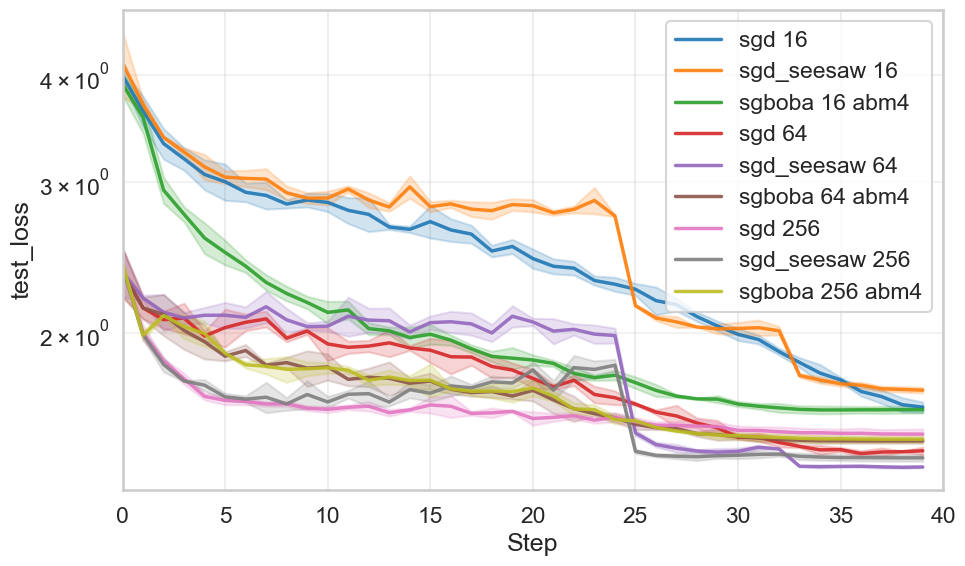

In [419]:
plot_metric_for_runs(
    metric='test_loss',
    runs=ALL_MAIN_RUNS,
    yscale='log',
    legend_loc='upper right',
    xlim=(0, 40),
)


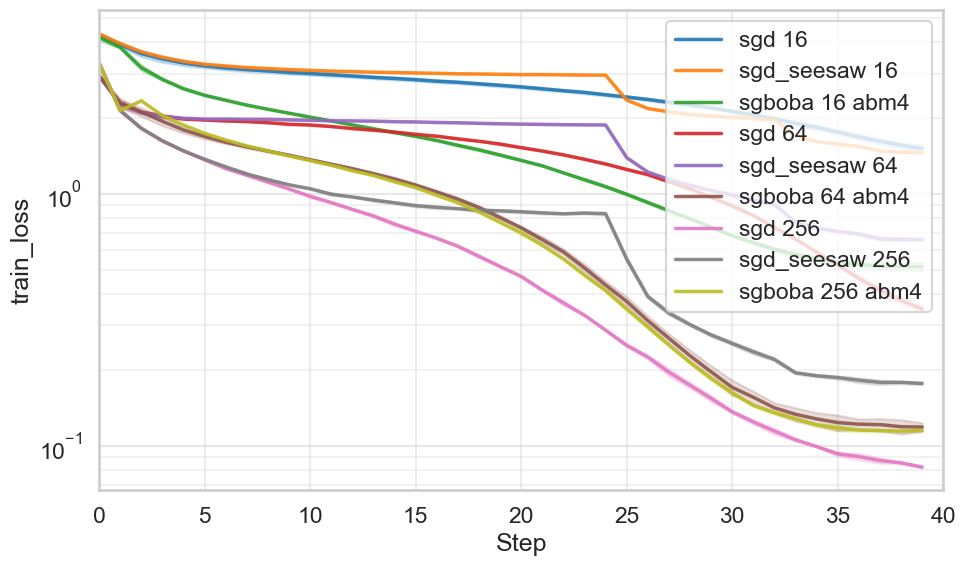

In [420]:
plot_metric_for_runs(
    metric='train_loss',
    runs=ALL_MAIN_RUNS,
    yscale='log',
    legend_loc='upper right',
    xlim=(0, 40),
)


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_50447/422462949.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


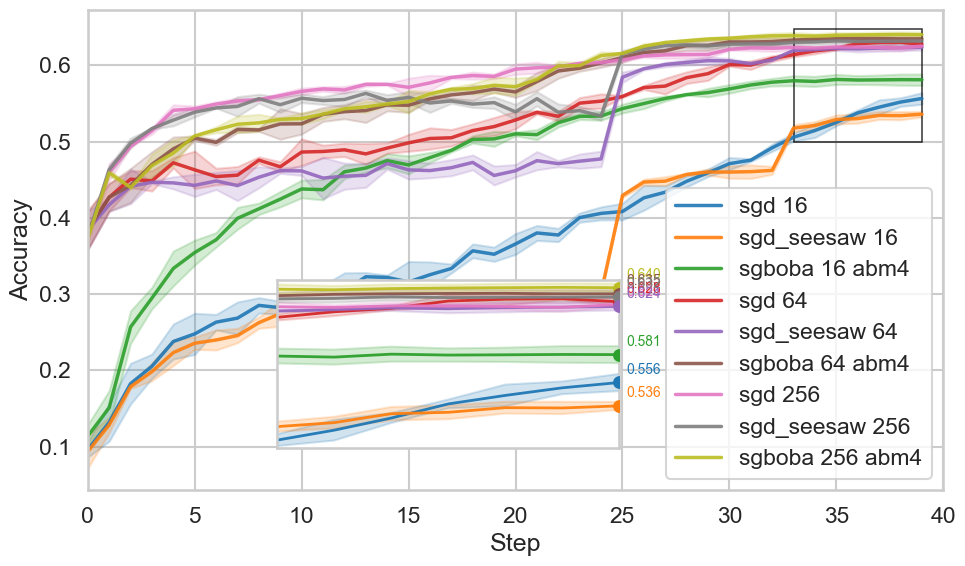

In [421]:
plot_accuracy_with_inset_for_runs(
    runs=ALL_MAIN_RUNS,
    legend_loc='lower right',
    inset_anchor=(0.2, 0.05, 1, 1),
    window=6,
    xlim=(0, 40),
)


Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__batch_size_combined.pdf


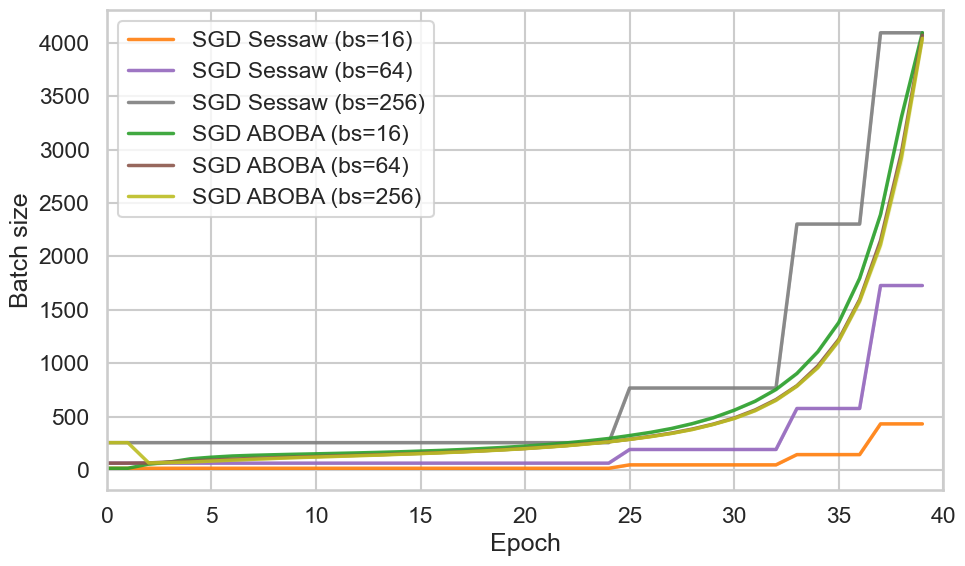

In [422]:
plot_batch_size_combined(
    ALL_BS,
    xlabel='Epoch',
    ylabel='Batch size',
    legend_loc='upper left',
    legend_label_fn=lambda run: (
    f"SGD Sessaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
    else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
    else run
    ),
    save_pdf=True,
    xlim=(0, 40),
)


Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__test_loss__baseline__bs16.pdf


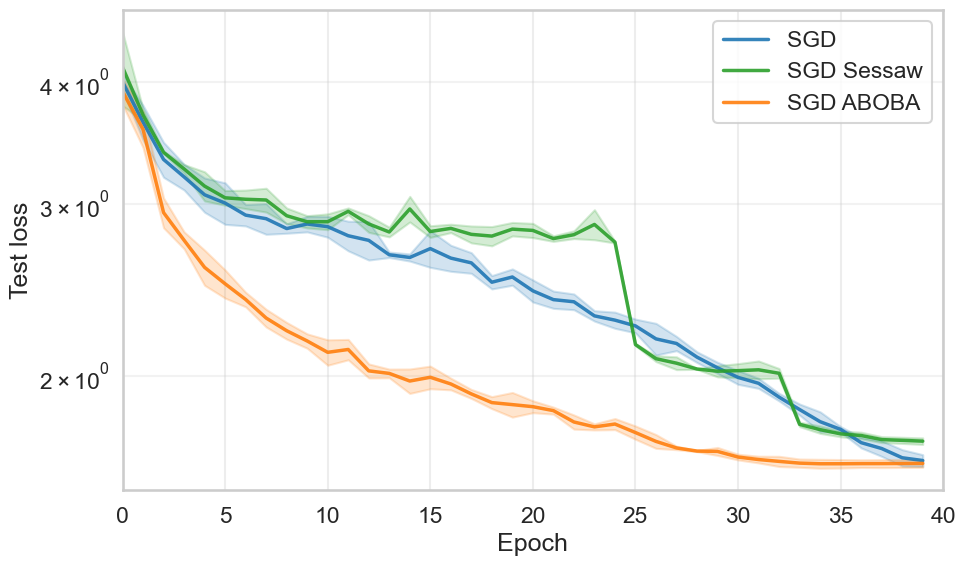

Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__test_loss__baseline__bs64.pdf


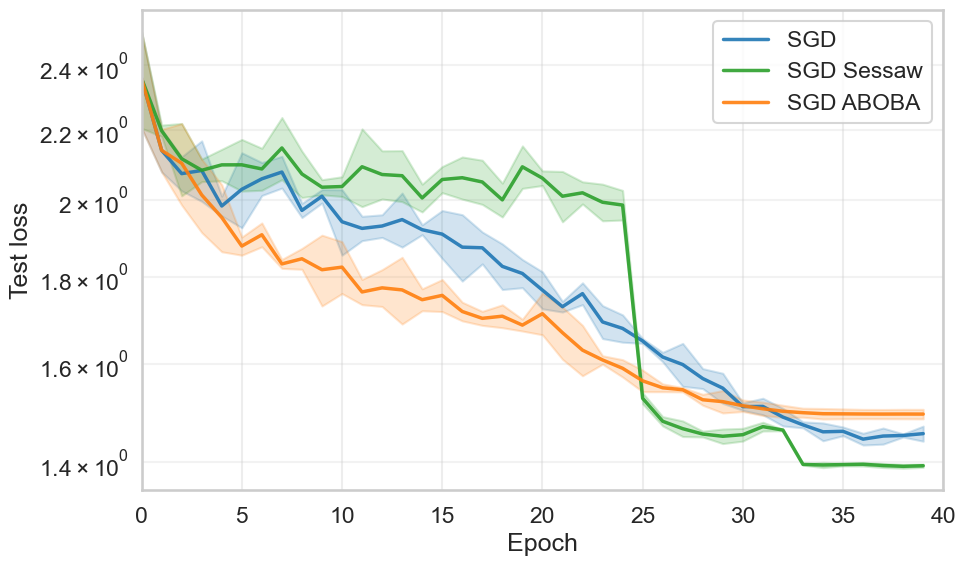

Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__test_loss__baseline__bs256.pdf


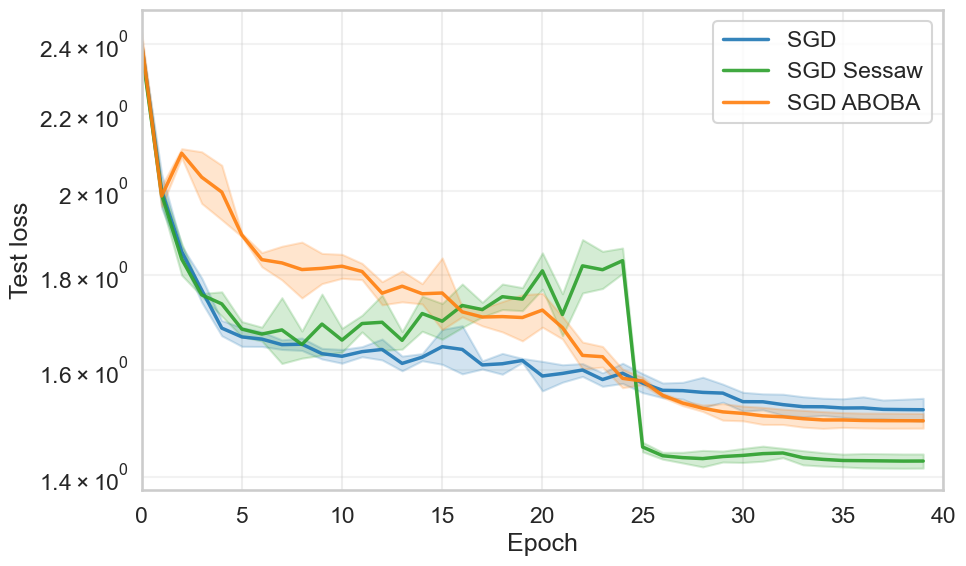

In [423]:
plot_metric_by_batch(
    metric='test_loss',
    batch_sizes=BASELINE_BS,
    mode='baseline',
    title_prefix='test loss vs epoch',
    yscale='log',
    xlabel='Epoch',
    ylabel='Test loss',
    legend_loc='upper right',
    legend_label_fn=lambda run: (
        f"SGD Sessaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    save_pdf=True,
    xlim=(0, 40),
)


Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__train_loss__baseline__bs16.pdf


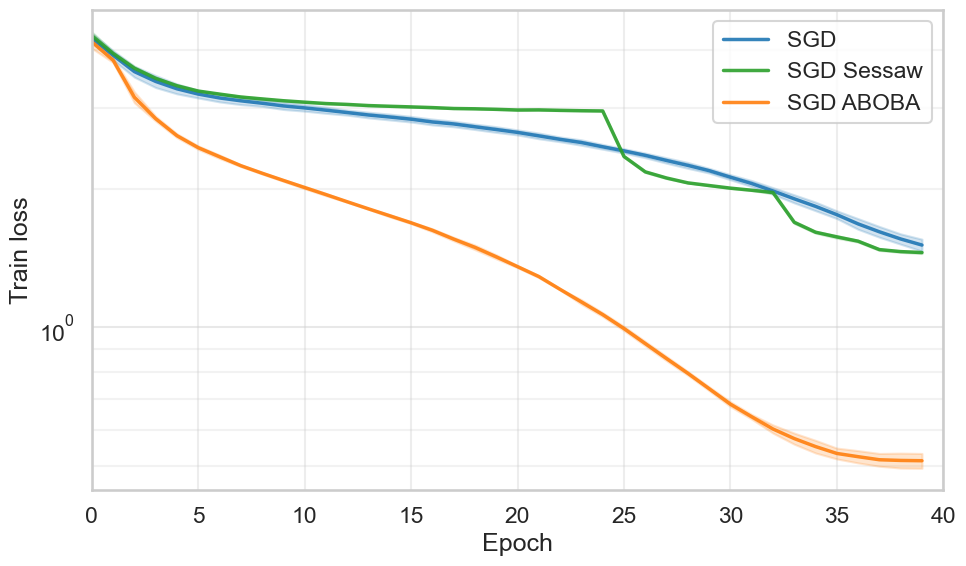

Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__train_loss__baseline__bs64.pdf


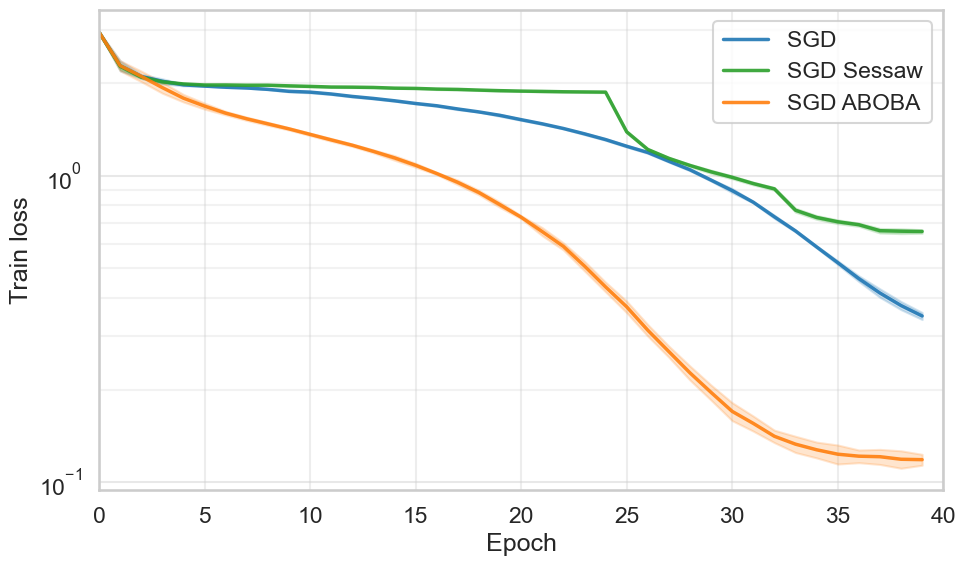

Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__metric__train_loss__baseline__bs256.pdf


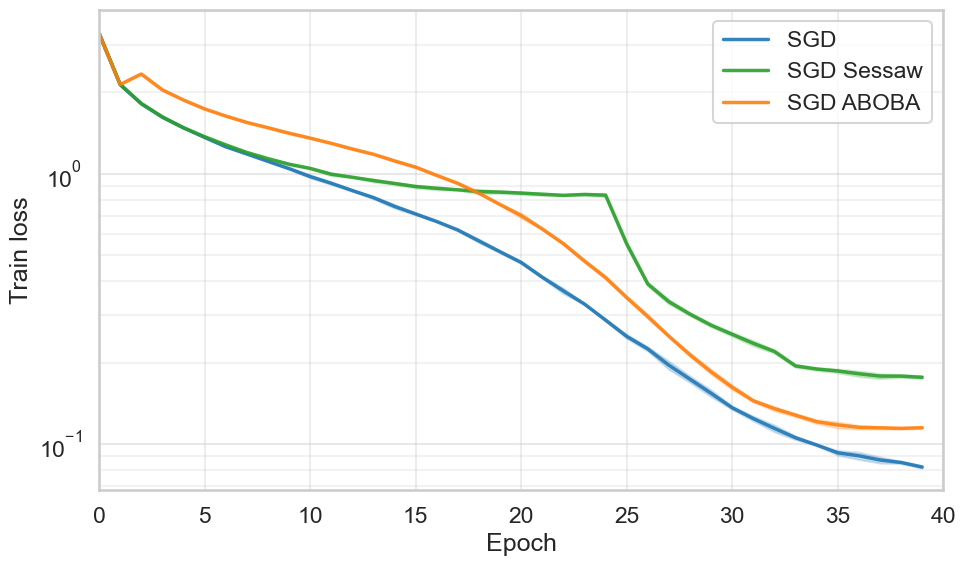

In [424]:
plot_metric_by_batch(
    metric='train_loss',
    batch_sizes=BASELINE_BS,
    mode='baseline',
    title_prefix='train loss vs epoch',
    yscale='log',
    legend_loc='upper right',
    xlabel='Epoch',
    ylabel='Train loss',
    legend_label_fn=lambda run: (
        f"SGD Sessaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    save_pdf=True,
    xlim=(0, 40),
)


Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__accuracy__baseline__bs16.pdf


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_50447/422462949.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


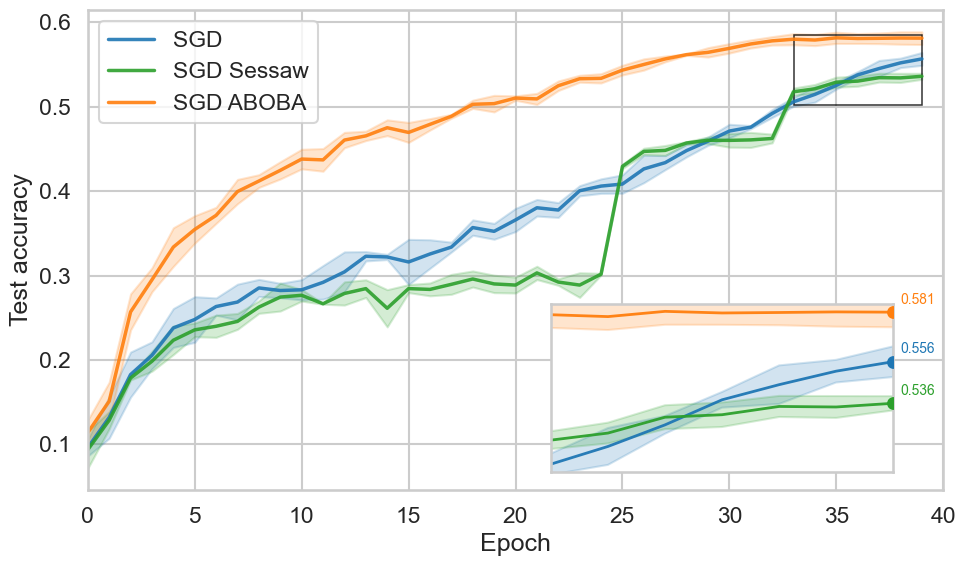

/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_50447/422462949.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__accuracy__baseline__bs64.pdf


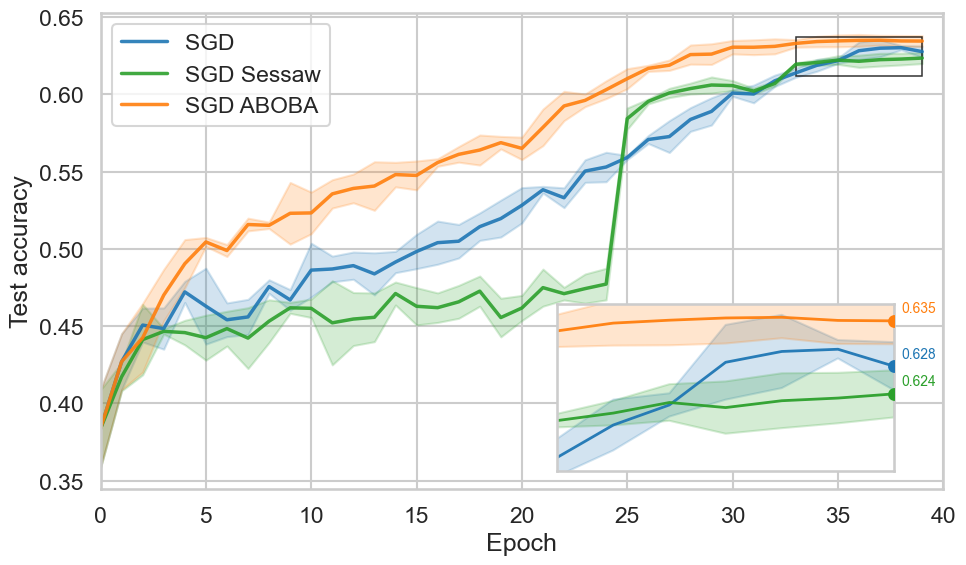

Saved PDF: paper/Achieving Linear Rate With Adaptive Batching/notebooks/figures/sgd_cifar100__accuracy__baseline__bs256.pdf


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_50447/422462949.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


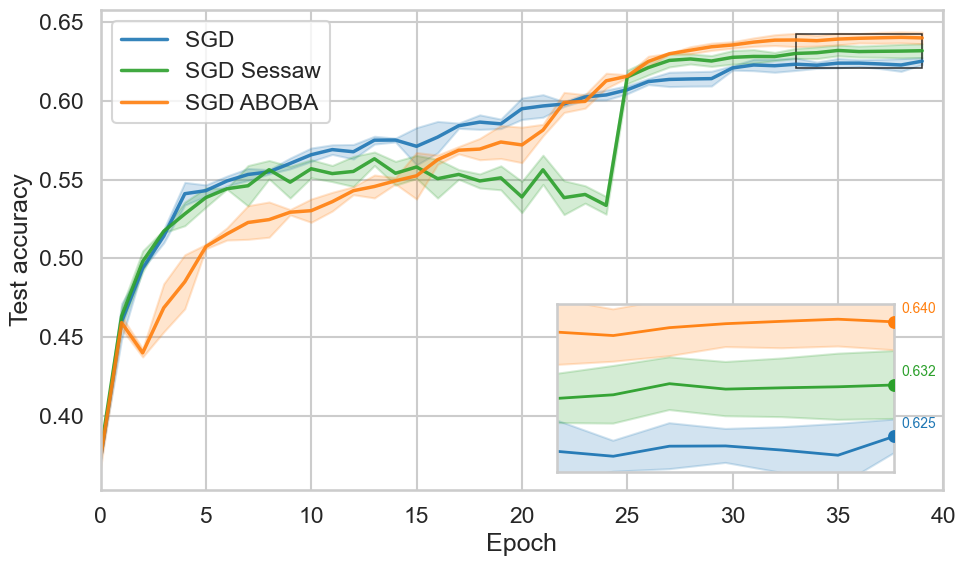

In [425]:
plot_accuracy_by_batch(
    batch_sizes=BASELINE_BS,
    mode='baseline',
    title_prefix='test accuracy vs epoch',
    legend_loc='upper left',
    inset_anchor=(0.52, 0.00, 1, 1),
    window=6,
    xlabel='Epoch',
    ylabel='Test accuracy',
    legend_label_fn=lambda run: (
        f"SGD Sessaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    save_pdf=True,
    xlim=(0, 40),
)


In [426]:
plot_metric_by_batch(
    metric='test_loss',
    batch_sizes=ABOBA_BS,
    mode='aboba',
    title_prefix='CIFAR100 ResNet34 SGD: Aboba test loss vs step',
    yscale='log',
    legend_loc='upper right',
    xlim=(0, 40),
)

plot_metric_by_batch(
    metric='train_loss',
    batch_sizes=ABOBA_BS,
    mode='aboba',
    title_prefix='CIFAR100 ResNet34 SGD: Aboba train loss vs step',
    yscale='log',
    legend_loc='upper right',
    legend_label_fn=lambda run: (
        f"SGD Sessaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 40),
)


Skip `test_loss`: fewer than 2 runs to plot.
Skip `test_loss`: fewer than 2 runs to plot.
Skip `test_loss`: fewer than 2 runs to plot.
Skip `train_loss`: fewer than 2 runs to plot.
Skip `train_loss`: fewer than 2 runs to plot.
Skip `train_loss`: fewer than 2 runs to plot.


In [427]:
plot_accuracy_by_batch(
    batch_sizes=ABOBA_BS,
    mode='aboba',
    title_prefix='CIFAR100 ResNet34 SGD: Aboba test accuracy vs step',
    legend_loc='lower right',
    inset_anchor=(0.2, 0.05, 1, 1),
    window=6,
    legend_label_fn=lambda run: (
        f"SGD Sessaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 40),
)


Skip `test_accuracy`: fewer than 2 runs to plot.
Skip `test_accuracy`: fewer than 2 runs to plot.
Skip `test_accuracy`: fewer than 2 runs to plot.


In [428]:
print('Per-batch aboba batch-size plots are disabled: use combined batch-size plot from cell 11.')


Per-batch aboba batch-size plots are disabled: use combined batch-size plot from cell 11.
